In [1]:
import os
import numpy as np
import rioxarray as rxr
import matplotlib.pyplot as plt
import pdb
from pathlib import Path
import string
import matplotlib.cm as cm
from matplotlib.legend_handler import HandlerTuple

In [2]:
basepath = Path("D:/MyDrive/Stability/RawData/Monthly_Averages/Masked/Combined")
months_full = ['December','January','February','March','April','May']
months = ['DEC','JAN','FEB','MAR','APR','MAY']

# Dictionary to hold distributions
distributions = {}

# Loop through months
for month in months:
    month_folder = basepath / month
    subregion_distributions = {}
    
    # Loop through the 11 files (subregions)
    for i in range(1, 12):
        filename = f"{month}{i}.tif"
        filepath = month_folder / filename
        
        # Open raster
        raster = rxr.open_rasterio(filepath, masked=True).squeeze()
        
        # Flatten and clean values
        values = raster.values.flatten()
        nodata_values = [-9999, 0]
        values = values[~np.isin(values, nodata_values)]
        values = values[~np.isnan(values)]
        
        # Store by subregion key
        subregion_distributions[f"Subregion {i}"] = values
    
    # Store by month
    distributions[month] = subregion_distributions

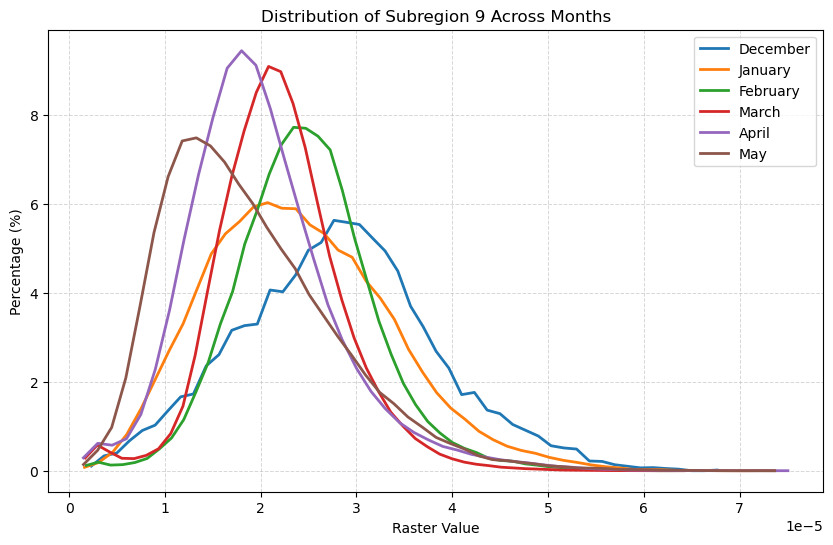

In [3]:
subregion = "Subregion 9"

# Map short codes to full names
month_map = dict(zip(months, months_full))

plt.figure(figsize=(10,6))

for month in months:
    values = distributions[month][subregion]
    
    # Compute histogram (counts, not density)
    counts, bin_edges = np.histogram(values, bins=50)
    counts_percent = counts / counts.sum() * 100  # convert to %
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Plot as percentages
    plt.plot(bin_centers, counts_percent, label=month_map[month], linewidth=2)

plt.xlabel("Raster Value")
plt.ylabel("Percentage (%)")
plt.title(f"Distribution of {subregion} Across Months")
plt.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.5)
plt.legend()
plt.show()

C:\Users\aeinhorn\AppData\Local\Temp\ipykernel_7488\944264008.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues')


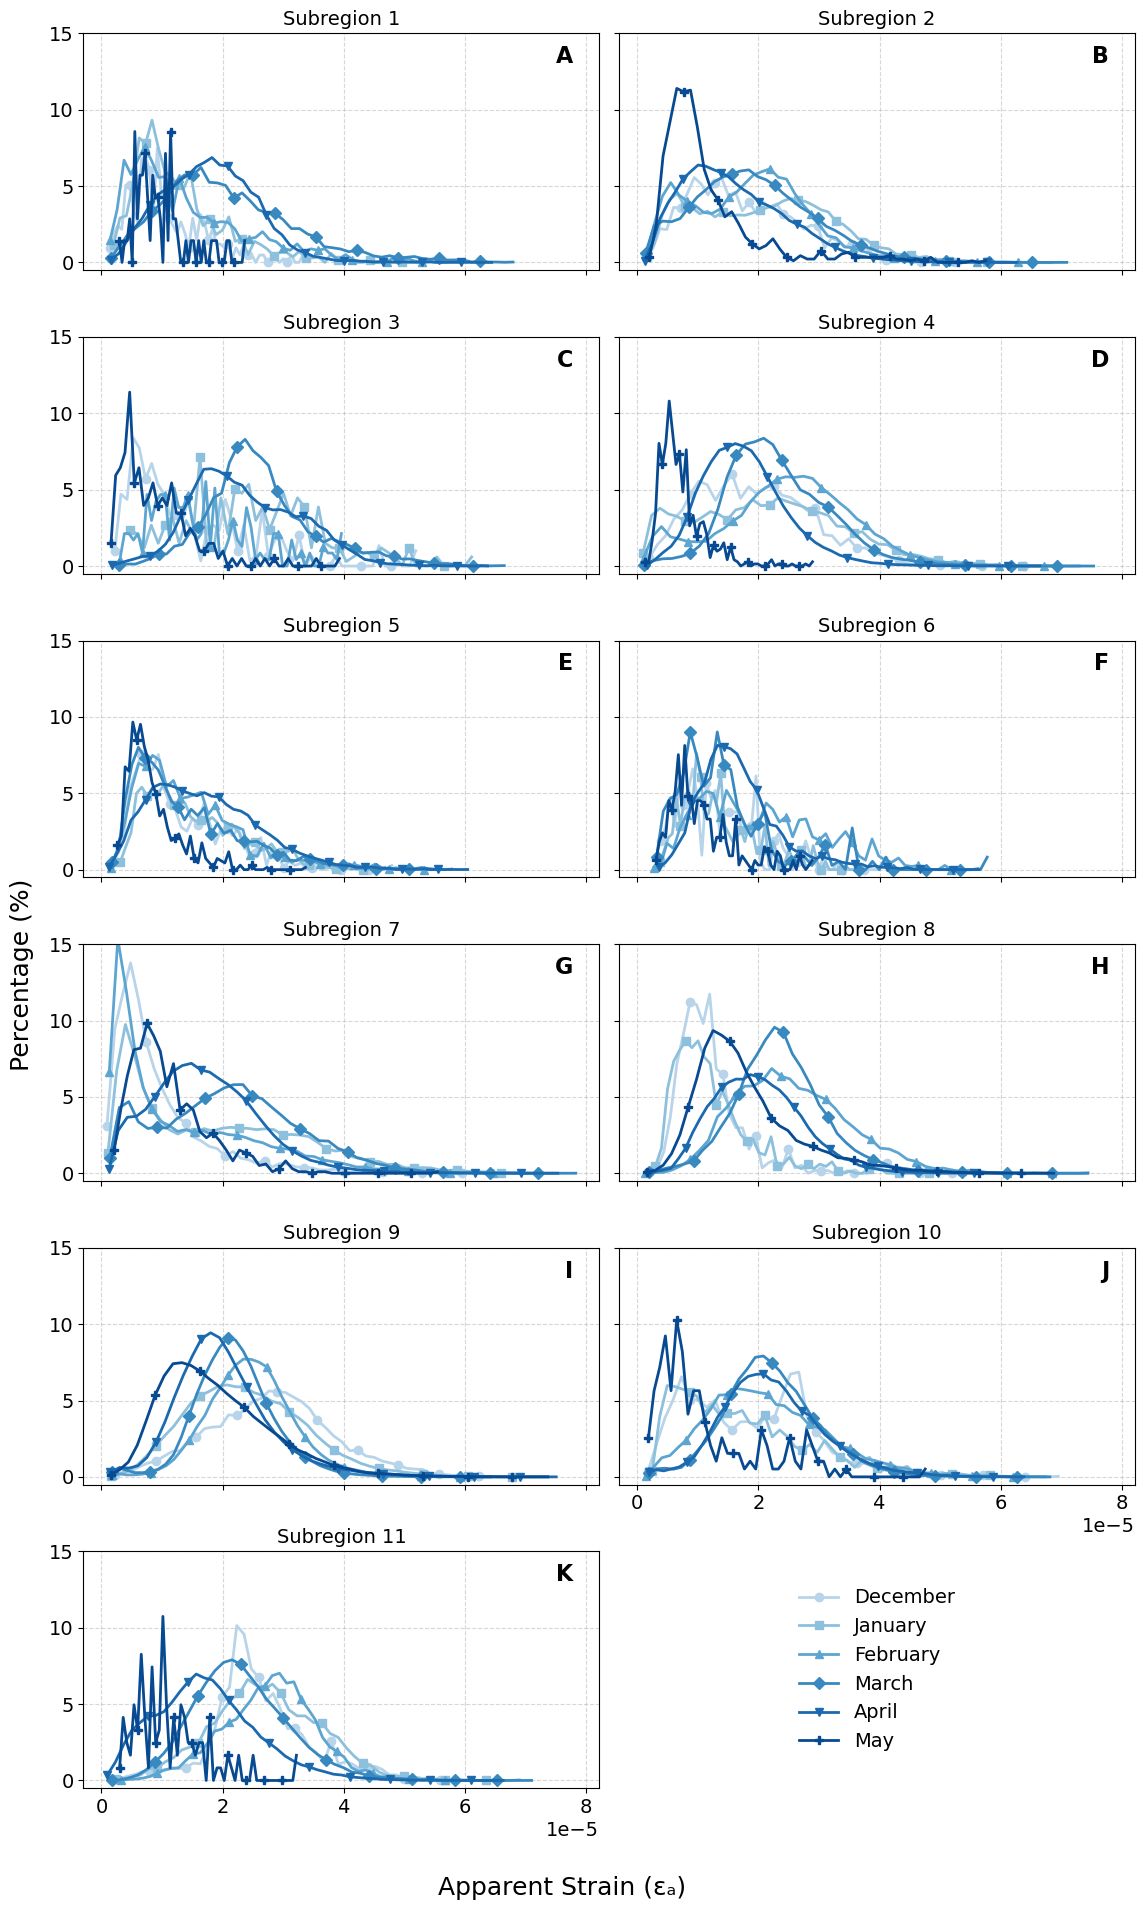

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import string

# Subregions
subregions = [f"Subregion {i}" for i in range(1, 12)]
month_map = dict(zip(months, months_full))

# Color and marker palettes
cmap = cm.get_cmap('Blues')
colors = [cmap(i) for i in np.linspace(0.3, 0.9, len(months))]
markers = ['o', 's', '^', 'D', 'v', 'P']  # one per month

# Letters for subplot labels
letters = list(string.ascii_uppercase)

# Figure setup (4 rows x 3 cols, last subplot for legend)
fig, axes = plt.subplots(6, 2, figsize=(12, 20), sharex=True, sharey=True)
axes = axes.flatten()

# Store lines for legend
legend_lines = []

for idx, (ax, subregion) in enumerate(zip(axes, subregions)):
    for (m, m_full, color, marker) in zip(months, months_full, colors, markers):
        values = distributions[m][subregion]
        
        counts, bin_edges = np.histogram(values, bins=50)
        counts_percent = counts / counts.sum() * 100
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        line, = ax.plot(bin_centers, counts_percent, label=m_full,
                        color=color, linewidth=2, marker=marker, markevery=5)
        
        # Save legend handles only once
        if idx == 0:
            legend_lines.append(line)
    
    ax.set_ylim([-0.5, 15])
    ax.set_title(subregion, fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.xaxis.get_offset_text().set_fontsize(14)
    # Add capital letter in top-right corner
    ax.text(0.95, 0.95, letters[idx], transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='right')
    
    # Enable x-ticks for Subregion 9
    if subregion == "Subregion 10":
        ax.tick_params(axis='x', bottom=True, labelbottom=True)

# Use the last subplot (12th) for the legend
legend_ax = axes[-1]
legend_ax.axis('off')
legend_ax.legend(handles=legend_lines, labels=months_full,
                 loc='center', fontsize=14, frameon=False)

# Common labels
fig.text(0.5, 0.04, "Apparent Strain (εₐ)", ha='center', fontsize=18)
fig.text(0.04, 0.5, "Percentage (%)", va='center', rotation='vertical', fontsize=18)

plt.tight_layout(rect=[0.06, 0.06, 0.99, 0.99])
plt.show()
fig.savefig("D:/MyDrive/Stability/Figs/subregion_distributions.png", dpi=300, bbox_inches="tight") 

C:\Users\aeinhorn\AppData\Local\Temp\ipykernel_7488\2457939551.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('magma')


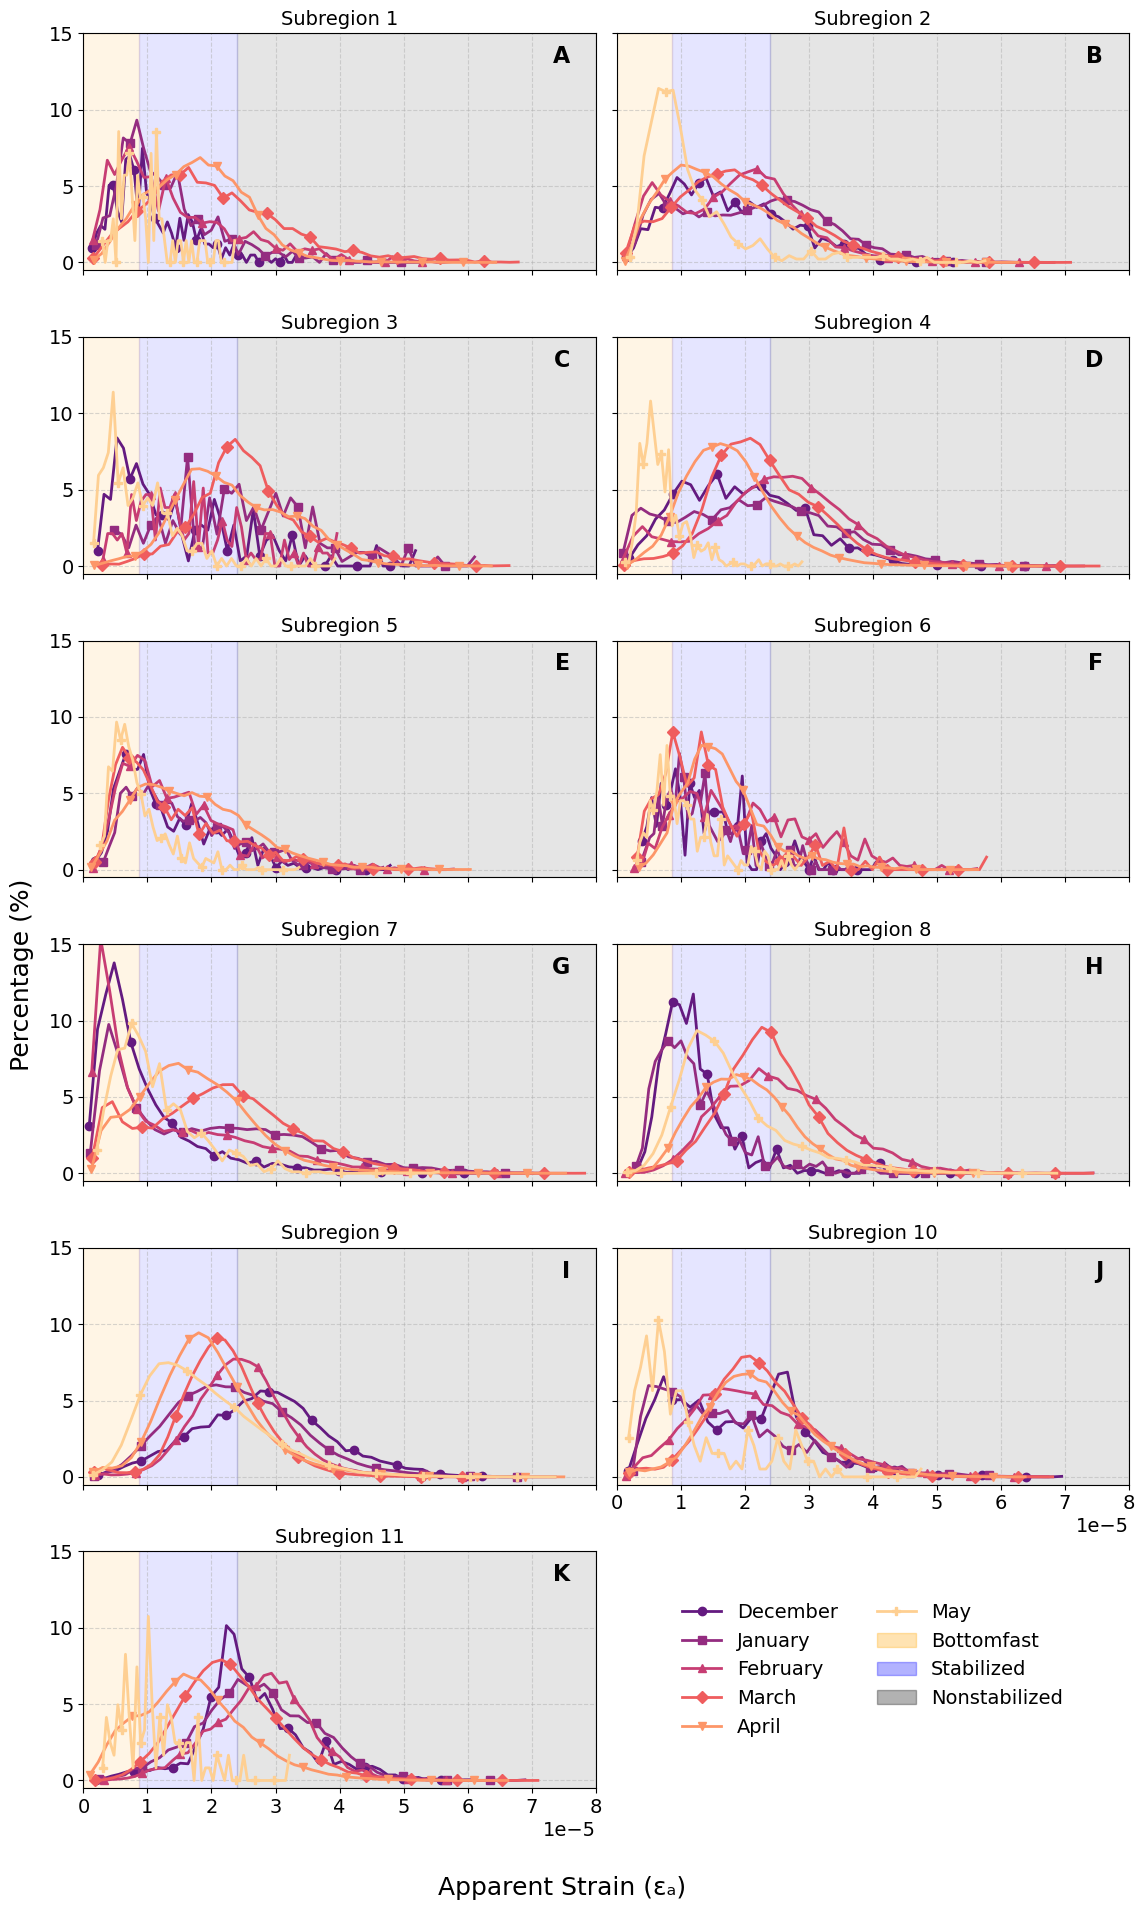

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import string
import matplotlib.patches as mpatches

# Subregions
subregions = [f"Subregion {i}" for i in range(1, 12)]
month_map = dict(zip(months, months_full))

# Color and marker palettes
cmap = cm.get_cmap('magma')
colors = [cmap(i) for i in np.linspace(0.3, 0.9, len(months))]
markers = ['o', 's', '^', 'D', 'v', 'P']  # one per month

# Letters for subplot labels
letters = list(string.ascii_uppercase)

# Shaded x-axis ranges with colors + labels
shaded_ranges = [
    (0, 8.6e-06, "orange", "Bottomfast"),
    (8.6e-06, 2.4e-05, "blue", "Stabilized"),
    (2.4e-05, 8e-05, "black", "Nonstabilized"),
]

# Figure setup (6 rows x 2 cols, last subplot for legend)
fig, axes = plt.subplots(6, 2, figsize=(12, 20), sharex=True, sharey=True)
axes = axes.flatten()

# Store lines for legend
legend_lines = []

for idx, (ax, subregion) in enumerate(zip(axes, subregions)):
    for (m, m_full, color, marker) in zip(months, months_full, colors, markers):
        values = distributions[m][subregion]
        
        counts, bin_edges = np.histogram(values, bins=50)
        counts_percent = counts / counts.sum() * 100
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        line, = ax.plot(bin_centers, counts_percent, label=m_full,
                        color=color, linewidth=2, marker=marker, markevery=5)
        
        # Save legend handles only once
        if idx == 0:
            legend_lines.append(line)

    # Add shaded regions with specified colors
    for xmin, xmax, col, _ in shaded_ranges:
        ax.axvspan(xmin, xmax, color=col, alpha=0.1)

    ax.set_ylim([-0.5, 15])
    ax.set_title(subregion, fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.xaxis.get_offset_text().set_fontsize(14)
    ax.set_xlim([0,8e-05])
    # Add capital letter in top-right corner
    ax.text(0.95, 0.95, letters[idx], transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='right')
    
    # Enable x-ticks for Subregion 10
    if subregion == "Subregion 10":
        ax.tick_params(axis='x', bottom=True, labelbottom=True)

# Custom patches for shaded regions
patches = [mpatches.Patch(color=col, alpha=0.3, label=label) for _, _, col, label in shaded_ranges]

# Use the last subplot (12th) for the legend
legend_ax = axes[-1]
legend_ax.axis('off')
legend_ax.legend(handles=legend_lines + patches,
                 labels=months_full + [lbl for _, _, _, lbl in shaded_ranges],
                 loc='center', fontsize=14, frameon=False, ncol=2)
# Common labels
fig.text(0.5, 0.04, "Apparent Strain (εₐ)", ha='center', fontsize=18)
fig.text(0.04, 0.5, "Percentage (%)", va='center', rotation='vertical', fontsize=18)

plt.tight_layout(rect=[0.06, 0.06, 0.99, 0.99])
plt.show()
fig.savefig("D:/MyDrive/Stability/Figs/subregion_distributions_shaded_05_02_26.png", dpi=300, bbox_inches="tight") 